# Reload saved model and forecast historical major flood events

This notebook reloads the trained model + scaling parameters (no need to retrain) and generates **rolling forecasts** over four historical major flood events. For each event, a new forecast is issued every `forecast_frequency_hours`, each one covering `forecast_horizon_hours` ahead at `prediction_timestep_hours` resolution, from `requested_prediction_start_utc` to `requested_prediction_end_utc`.

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO
from tensorflow.keras.models import load_model

# ---- Paths: update these if your files live elsewhere ----
RAW_DATA_PATH = "/bsuhome/amirhosseinmonta/scratch/watersofthack/USGS_gage_data/usgs_gauge_height_streamflow_long_filled.csv"
MODEL_PATH = "/bsuhome/amirhosseinmonta/scratch/watersofthack/USGS_gage_data/gage_height_lstm_08210000_18h_final_4500.keras"
SCALING_PATH = "/bsuhome/amirhosseinmonta/scratch/watersofthack/USGS_gage_data/gage_height_scaling_parameters_18h_final_4500.csv"
PARAMETER = "gage_height_ft"

## Load the saved model and scaling parameters

The scaling file's row order **is** the feature-gauge order the model was trained on, so we read it from there instead of re-typing it by hand (which would risk getting the column order wrong and silently feeding the model mismatched features).

In [58]:
model = load_model(MODEL_PATH)

scaling_parameters = pd.read_csv(SCALING_PATH, index_col=0)
scaling_parameters.index = (
    scaling_parameters.index.astype(str).str.zfill(8)
)

feature_mean = scaling_parameters["mean"]
feature_std = scaling_parameters["std"]

FEATURE_GAUGES = feature_mean.index.tolist()
TARGET_GAUGE = "08210000"

target_mean = feature_mean[TARGET_GAUGE]
target_std = feature_std[TARGET_GAUGE]

# The Input layer's shape is frozen into the saved model, so trust the
# model itself for lookback/horizon rather than any external spec.
_, MODEL_LOOKBACK_HOURS, MODEL_NUM_FEATURES = model.input_shape
MODEL_FORECAST_HOURS = model.output_shape[1]

print("Loaded model:")
print("  lookback hours :", MODEL_LOOKBACK_HOURS)
print("  forecast hours :", MODEL_FORECAST_HOURS)
print("  feature gauges :", FEATURE_GAUGES)


Loaded model:
  lookback hours : 168
  forecast hours : 18
  feature gauges : ['08210000', '08194000', '08194500']


## The requested events

Pasted directly from your table so this notebook is self-contained. **Note:** the table's `input_history_hours` column says `12`, but the saved model requires exactly `MODEL_LOOKBACK_HOURS` hours of input history — that length is baked into the network and can't be changed at inference time. The cell below checks for this and, if they differ, uses the model's real requirement (and tells you so) rather than silently guessing which one you meant.

In [59]:
EVENT_TABLE_CSV = """event_rank,target_site_id,major_event_start_utc,major_event_end_utc,major_event_duration_hours,observed_peak_stage_ft,requested_prediction_start_utc,requested_prediction_end_utc,input_history_hours,forecast_frequency_hours,forecast_horizon_hours,prediction_timestep_hours
1,08210000,2013-10-20 03:00:00+00:00,2013-10-26 21:15:00+00:00,162.25,38.95,2013-10-17 00:00:00+00:00,2013-10-30 00:00:00+00:00,12,12,12,1
2,08210000,2015-05-17 14:15:00+00:00,2015-05-20 22:15:00+00:00,80.0,37.94,2015-05-14 00:00:00+00:00,2015-05-24 00:00:00+00:00,12,12,12,1
3,08210000,2022-08-22 02:15:00+00:00,2022-08-24 01:00:00+00:00,46.75,37.08,2022-08-19 00:00:00+00:00,2022-08-28 00:00:00+00:00,12,12,12,1
4,08210000,2018-10-31 11:45:00+00:00,2018-11-01 11:15:00+00:00,23.5,35.17,2018-10-28 00:00:00+00:00,2018-11-05 00:00:00+00:00,12,12,12,1
"""

events = pd.read_csv(StringIO(EVENT_TABLE_CSV))

for col in [
    "major_event_start_utc", "major_event_end_utc",
    "requested_prediction_start_utc", "requested_prediction_end_utc",
]:
    events[col] = pd.to_datetime(events[col], utc=True)

events["target_site_id"] = events["target_site_id"].astype(str).str.zfill(8)

if (events["forecast_horizon_hours"] != MODEL_FORECAST_HOURS).any():
    print(
        f"Warning: requested forecast_horizon_hours differs from the "
        f"model's trained horizon ({MODEL_FORECAST_HOURS}h) for some "
        f"events. Using the model's horizon regardless."
    )

if (events["input_history_hours"] != MODEL_LOOKBACK_HOURS).any():
    print(
        f"Note: the event table asks for "
        f"{events['input_history_hours'].iloc[0]}h of input history, but "
        f"this saved model was trained with a fixed "
        f"{MODEL_LOOKBACK_HOURS}h lookback window. Using "
        f"{MODEL_LOOKBACK_HOURS}h of history for every forecast below."
    )

events


Note: the event table asks for 12h of input history, but this saved model was trained with a fixed 168h lookback window. Using 168h of history for every forecast below.


,event_rank,target_site_id,major_event_start_utc,major_event_end_utc,major_event_duration_hours,observed_peak_stage_ft,requested_prediction_start_utc,requested_prediction_end_utc,input_history_hours,forecast_frequency_hours,forecast_horizon_hours,prediction_timestep_hours
0,1,08210000,2013-10-20 03:00:00+00:00,2013-10-26 21:15:00+00:00,162.25,38.95,2013-10-17 00:00:00+00:00,2013-10-30 00:00:00+00:00,12,12,12,1
1,2,08210000,2015-05-17 14:15:00+00:00,2015-05-20 22:15:00+00:00,80.00,37.94,2015-05-14 00:00:00+00:00,2015-05-24 00:00:00+00:00,12,12,12,1
2,3,08210000,2022-08-22 02:15:00+00:00,2022-08-24 01:00:00+00:00,46.75,37.08,2022-08-19 00:00:00+00:00,2022-08-28 00:00:00+00:00,12,12,12,1
3,4,08210000,2018-10-31 11:45:00+00:00,2018-11-01 11:15:00+00:00,23.50,35.17,2018-10-28 00:00:00+00:00,2018-11-05 00:00:00+00:00,12,12,12,1


## Rebuild the hourly stage series

Same pipeline as training (dedupe duplicate timestamps with `mean`, resample to hourly with `max` to preserve peaks, fill only short gaps) so the model sees data prepared exactly the way it was trained.

In [60]:
def load_stage_hourly(csv_path, feature_gauges, parameter=PARAMETER):
    data = pd.read_csv(csv_path)

    data["datetime"] = pd.to_datetime(
        data["datetime"], utc=True, errors="coerce"
    )
    data["site_id"] = (
        data["site_id"].astype(str)
        .str.replace(r"\.0$", "", regex=True)
        .str.zfill(8)
    )
    data["value"] = pd.to_numeric(data["value"], errors="coerce")

    stage_long = data.loc[
        (data["parameter_name"] == parameter)
        & (data["site_id"].isin(feature_gauges)),
        ["datetime", "site_id", "value"],
    ].dropna().sort_values("datetime")

    stage_wide_15min = (
        stage_long
        .pivot_table(
            index="datetime", columns="site_id",
            values="value", aggfunc="mean",
        )
        .sort_index()
        .reindex(columns=feature_gauges)
    )

    stage_hourly = stage_wide_15min.resample("1h").max()

    # Fill only short gaps, same limit used during training
    stage_hourly = stage_hourly.interpolate(
        method="time", limit=2, limit_area="inside"
    )

    return stage_hourly, data


stage_hourly, raw_data = load_stage_hourly(RAW_DATA_PATH, FEATURE_GAUGES)

print("Hourly data covers:", stage_hourly.index.min(), "to", stage_hourly.index.max())
print(stage_hourly.isna().mean().rename("fraction_missing"))


Hourly data covers: 2010-01-01 06:00:00+00:00 to 2026-07-27 20:00:00+00:00
site_id
08210000    0.001776
08194000    0.015347
08194500    0.003670
Name: fraction_missing, dtype: float64


## Append a new event's data to the hourly record

If you have raw readings for an event that isn't in `RAW_DATA_PATH` (e.g. a very recent flood, or data pulled from a different source), you can fold it into `stage_hourly` here rather than editing the raw CSV. **Assign your data to `new_event_data` below (not `event`) -- `event` is already used as the loop variable everywhere else in this notebook, and reusing the name would silently overwrite it.**

Expected input: a DataFrame with a `datetime` column and one column per gauge, e.g. `USGS_08210000_gauge_height_ft`. This is reshaped to match `stage_hourly`'s format (bare site-ID columns, `datetime` as the index) and checked against `FEATURE_GAUGES` -- the exact set of gauges this saved model needs -- before anything is appended.

In [61]:
event = pd.read_csv('/bsuhome/amirhosseinmonta/scratch/watersofthack/USGS_gage_data/USGS_08210000_ReachID_3168766_NWM_analysis_7d_short_range_18h_2026073019_nwm_usgs_comparison.csv')


In [62]:
event

,datetime,data_type,init_time,USGS_08194000_gauge_height_ft,USGS_08194500_gauge_height_ft,USGS_08210000_gauge_height_ft,USGS_08194000_qualifier,USGS_08194500_qualifier,USGS_08210000_qualifier,USGS_08194000_observation_available,USGS_08194500_observation_available,USGS_08210000_observation_available
0,2026-07-23 19:00:00+00:00,analysis_assim,2026-07-23 19:00:00+00:00,27.20,2.04,1.31,P,P,P,True,True,True
1,2026-07-23 20:00:00+00:00,analysis_assim,2026-07-23 20:00:00+00:00,27.12,2.04,1.31,P,P,P,True,True,True
2,2026-07-23 21:00:00+00:00,analysis_assim,2026-07-23 21:00:00+00:00,26.97,2.04,1.31,P,P,P,True,True,True
3,2026-07-23 22:00:00+00:00,analysis_assim,2026-07-23 22:00:00+00:00,26.87,2.04,1.31,P,P,P,True,True,True
4,2026-07-23 23:00:00+00:00,analysis_assim,2026-07-23 23:00:00+00:00,26.81,2.03,1.31,P,P,P,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...
182,2026-07-31 09:00:00+00:00,short_range,2026-07-30 19:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False
183,2026-07-31 10:00:00+00:00,short_range,2026-07-30 19:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False
184,2026-07-31 11:00:00+00:00,short_range,2026-07-30 19:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False
185,2026-07-31 12:00:00+00:00,short_range,2026-07-30 19:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False


In [63]:
new_event_data = event[['datetime','USGS_08194000_gauge_height_ft','USGS_08194500_gauge_height_ft','USGS_08210000_gauge_height_ft']]

In [64]:
import re

def prepare_event_frame(new_event_data, feature_gauges):
    frame = new_event_data.copy()
    frame["datetime"] = pd.to_datetime(frame["datetime"], utc=True)
    frame = frame.set_index("datetime").sort_index()

    def strip_to_site_id(column_name):
        match = re.search(r"(\d{7,8})", column_name)
        return match.group(1).zfill(8) if match else column_name

    frame.columns = [strip_to_site_id(c) for c in frame.columns]

    missing = [g for g in feature_gauges if g not in frame.columns]
    extra = [c for c in frame.columns if c not in feature_gauges]

    if missing:
        raise ValueError(
            f"This event data is missing gauge(s) the model needs: "
            f"{missing}. The model expects exactly: {feature_gauges}. "
            f"Either source that gauge's data for this event, or confirm "
            f"the model was actually trained on a different donor set."
        )
    if extra:
        print(f"Note: dropping columns the model doesn't use: {extra}")

    return frame.reindex(columns=feature_gauges)


# ---- Replace this with your actual new-event DataFrame ----
# new_event_data = event['datetime','USGS_08194000_gauge_height_ft', ...]

event_prepared = prepare_event_frame(new_event_data, FEATURE_GAUGES)

# Union with the existing record. Where timestamps overlap,
# event_prepared's values win (it's presumably the more authoritative
# / more recent reading) -- combine_first keeps the left frame's
# values and only fills gaps from the right frame.
stage_hourly = event_prepared.combine_first(stage_hourly).sort_index()

# Re-run the same hourly resample + short-gap fill used during training,
# in case the new data isn't exactly on the hour or there's a small gap
# where the two datasets join.
stage_hourly = stage_hourly.resample("1h").max()
stage_hourly = stage_hourly.interpolate(
    method="time", limit=2, limit_area="inside"
)

print(
    "Combined record now covers:",
    stage_hourly.index.min(), "to", stage_hourly.index.max(),
)
print(stage_hourly.loc[event_prepared.index.min():event_prepared.index.max()].isna().sum())

Combined record now covers: 2010-01-01 06:00:00+00:00 to 2026-07-31 13:00:00+00:00
08210000    15
08194000    15
08194500    15
dtype: int64


## Register the new event in the `events` table

Adding a row here means every cell below -- the 12-hour fan, the continuous nowcast/12-hour-ahead forecasts, the summary table, and the plots -- picks up this event automatically, since they all loop over `events.iterrows()`.

`observed_peak_stage_ft` is computed directly from your appended data (not guessed). `major_event_start_utc`/`major_event_end_utc` are just placeholders here (set to the peak time) since this notebook doesn't know the true flood boundaries -- edit those two if you know the actual start/end (they're only used for the plot title, not for the forecast itself).

In [65]:
peak_time

Timestamp('2026-07-30 22:00:00+0000', tz='UTC')

In [66]:
new_event_target = event_prepared[TARGET_GAUGE]
peak_time = new_event_target.idxmax()
peak_stage = new_event_target.max()

new_row = {
    "event_rank": int(events["event_rank"].max()) + 1,
    "target_site_id": TARGET_GAUGE,
    "major_event_start_utc": peak_time,  # placeholder -- edit if known
    "major_event_end_utc": peak_time,    # placeholder -- edit if known
    "major_event_duration_hours": np.nan,
    "observed_peak_stage_ft": peak_stage,
    "requested_prediction_start_utc": (
        event_prepared.index.min() + pd.Timedelta(hours=MODEL_LOOKBACK_HOURS)
    ),
    "requested_prediction_end_utc": event_prepared.index.max(),
    "input_history_hours": MODEL_LOOKBACK_HOURS,
    "forecast_frequency_hours": 18,
    "forecast_horizon_hours": MODEL_FORECAST_HOURS,
    "prediction_timestep_hours": 1,
}

events = pd.concat([events, pd.DataFrame([new_row])], ignore_index=True)
events

,event_rank,target_site_id,major_event_start_utc,major_event_end_utc,major_event_duration_hours,observed_peak_stage_ft,requested_prediction_start_utc,requested_prediction_end_utc,input_history_hours,forecast_frequency_hours,forecast_horizon_hours,prediction_timestep_hours
0,1,08210000,2013-10-20 03:00:00+00:00,2013-10-26 21:15:00+00:00,162.25,38.95,2013-10-17 00:00:00+00:00,2013-10-30 00:00:00+00:00,12,12,12,1
1,2,08210000,2015-05-17 14:15:00+00:00,2015-05-20 22:15:00+00:00,80.00,37.94,2015-05-14 00:00:00+00:00,2015-05-24 00:00:00+00:00,12,12,12,1
2,3,08210000,2022-08-22 02:15:00+00:00,2022-08-24 01:00:00+00:00,46.75,37.08,2022-08-19 00:00:00+00:00,2022-08-28 00:00:00+00:00,12,12,12,1
3,4,08210000,2018-10-31 11:45:00+00:00,2018-11-01 11:15:00+00:00,23.50,35.17,2018-10-28 00:00:00+00:00,2018-11-05 00:00:00+00:00,12,12,12,1
4,5,08210000,2026-07-30 22:00:00+00:00,2026-07-30 22:00:00+00:00,NaN,35.53,2026-07-30 19:00:00+00:00,2026-07-31 13:00:00+00:00,168,18,18,1


In [67]:
requested_prediction_end_utc = pd.Timestamp("2026-07-31 13:00:00", tz="UTC")
requested_prediction_start_utc = (
    requested_prediction_end_utc.normalize() - pd.Timedelta(days=10)
)
# normalize() -> 2026-07-31 00:00, minus 7 days -> 2026-07-24 00:00

mask = events["event_rank"] == 5

print("Before:")
print(events.loc[mask, ["event_rank", "requested_prediction_start_utc", "requested_prediction_end_utc"]])

events.loc[mask, "requested_prediction_start_utc"] = requested_prediction_start_utc

print("\nAfter:")
print(events.loc[mask, ["event_rank", "requested_prediction_start_utc", "requested_prediction_end_utc"]])

Before:
   event_rank requested_prediction_start_utc requested_prediction_end_utc
4           5      2026-07-30 19:00:00+00:00    2026-07-31 13:00:00+00:00

After:
   event_rank requested_prediction_start_utc requested_prediction_end_utc
4           5      2026-07-21 00:00:00+00:00    2026-07-31 13:00:00+00:00


In [68]:
events

,event_rank,target_site_id,major_event_start_utc,major_event_end_utc,major_event_duration_hours,observed_peak_stage_ft,requested_prediction_start_utc,requested_prediction_end_utc,input_history_hours,forecast_frequency_hours,forecast_horizon_hours,prediction_timestep_hours
0,1,08210000,2013-10-20 03:00:00+00:00,2013-10-26 21:15:00+00:00,162.25,38.95,2013-10-17 00:00:00+00:00,2013-10-30 00:00:00+00:00,12,12,12,1
1,2,08210000,2015-05-17 14:15:00+00:00,2015-05-20 22:15:00+00:00,80.00,37.94,2015-05-14 00:00:00+00:00,2015-05-24 00:00:00+00:00,12,12,12,1
2,3,08210000,2022-08-22 02:15:00+00:00,2022-08-24 01:00:00+00:00,46.75,37.08,2022-08-19 00:00:00+00:00,2022-08-28 00:00:00+00:00,12,12,12,1
3,4,08210000,2018-10-31 11:45:00+00:00,2018-11-01 11:15:00+00:00,23.50,35.17,2018-10-28 00:00:00+00:00,2018-11-05 00:00:00+00:00,12,12,12,1
4,5,08210000,2026-07-30 22:00:00+00:00,2026-07-30 22:00:00+00:00,NaN,35.53,2026-07-21 00:00:00+00:00,2026-07-31 13:00:00+00:00,168,18,18,1


## Flood-stage thresholds and classifier

Rebuilt here so this notebook doesn't depend on having run the training notebook first.

In [69]:
def get_thresholds(raw_data, target_gauge):
    threshold_columns = [
        "action_stage_ft", "minor_flood_stage_ft",
        "moderate_flood_stage_ft", "major_flood_stage_ft",
    ]
    target_metadata = raw_data.loc[
        raw_data["site_id"] == target_gauge, threshold_columns
    ]
    thresholds = {}
    for column in threshold_columns:
        values = pd.to_numeric(
            target_metadata[column], errors="coerce"
        ).dropna()
        thresholds[column] = float(values.iloc[-1]) if len(values) else np.nan
    return thresholds


def classify_stage(stage_ft, thresholds):
    if pd.isna(stage_ft):
        return np.nan
    if pd.notna(thresholds["major_flood_stage_ft"]) and stage_ft >= thresholds["major_flood_stage_ft"]:
        return "Major Flood"
    if pd.notna(thresholds["moderate_flood_stage_ft"]) and stage_ft >= thresholds["moderate_flood_stage_ft"]:
        return "Moderate Flood"
    if pd.notna(thresholds["minor_flood_stage_ft"]) and stage_ft >= thresholds["minor_flood_stage_ft"]:
        return "Minor Flood"
    if pd.notna(thresholds["action_stage_ft"]) and stage_ft >= thresholds["action_stage_ft"]:
        return "Action Stage"
    return "Below Action Stage"


thresholds = get_thresholds(raw_data, TARGET_GAUGE)
thresholds


{'action_stage_ft': 20.0,
 'minor_flood_stage_ft': 25.0,
 'moderate_flood_stage_ft': 27.0,
 'major_flood_stage_ft': 35.0}

## Rolling forecast generator

For a single event: starting at `requested_prediction_start_utc`, issue a forecast every `forecast_frequency_hours`, up through `requested_prediction_end_utc`. Each forecast uses the `MODEL_LOOKBACK_HOURS` hours immediately before the issue time as input and predicts `MODEL_FORECAST_HOURS` hours ahead at 1-hour steps. Windows with missing history are skipped (and reported) rather than silently fed to the model with NaNs.

In [70]:
def generate_rolling_forecasts(
    stage_hourly, model,
    feature_mean, feature_std, target_mean, target_std,
    feature_gauges, target_gauge,
    prediction_start, prediction_end,
    lookback_hours, forecast_hours,
    forecast_frequency_hours=18,
):
    scaled = (stage_hourly[feature_gauges] - feature_mean) / feature_std

    issue_times = pd.date_range(
        start=prediction_start,
        end=prediction_end,
        freq=f"{forecast_frequency_hours}h",
    )

    records = []

    for issue_time in issue_times:
        window = (
            scaled.loc[: issue_time - pd.Timedelta(hours=1)]
            .tail(lookback_hours)
        )

        if len(window) != lookback_hours:
            print(
                f"Skipping {issue_time}: only {len(window)}h of history "
                f"available (need {lookback_hours}h)."
            )
            continue

        if window.isna().any().any():
            print(f"Skipping {issue_time}: missing values in the input window.")
            continue

        x_input = window.to_numpy(dtype=np.float32)[np.newaxis, :, :]

        predicted_scaled = model.predict(x_input, verbose=0)[0]
        predicted_ft = predicted_scaled * target_std + target_mean

        forecast_times = pd.date_range(
            start=issue_time, periods=forecast_hours, freq="1h"
        )

        observed_ft = stage_hourly[target_gauge].reindex(forecast_times)

        for lead_hour, (forecast_time, pred, obs) in enumerate(
            zip(forecast_times, predicted_ft, observed_ft), start=1
        ):
            records.append({
                "issue_time": issue_time,
                "lead_hour": lead_hour,
                "forecast_time": forecast_time,
                "predicted_stage_ft": pred,
                "observed_stage_ft": obs,
            })

    return pd.DataFrame(records)


## A continuous forecast at a fixed lead time (any horizon)

The 12-hour fan above is issued only every 12 hours, so consecutive runs are independent and don't connect -- each arc starts fresh from its own lookback window, with no memory of the previous run's predictions. That produces the disconnected, step-like look, and it's more visible during the steep rising limb because each fresh 12-hour run tends to underpredict the rate of rise, so it 'resets' a bit below where the previous run left off.

The fix doesn't require giving up the 12-hour lead time -- it just requires re-issuing the forecast **every hour** instead of every 12 hours, and each time keeping only the single value at the lead hour you care about, rather than the whole 1-12 hour block. Strung together, that's a continuous series of genuine 12-hour-ahead forecasts (this is exactly how a 'T+12h forecast' is usually shown operationally -- re-forecast every time step, chart only the fixed horizon of interest). Below, `lead_hour=1` gives a tight nowcast and `lead_hour=MODEL_FORECAST_HOURS` gives the true continuous 12-hour lead-time forecast -- same underlying model and horizon as the fan chart, just sampled every hour instead of every 12.

In [71]:
def generate_continuous_forecast(
    stage_hourly, model,
    feature_mean, feature_std, target_mean, target_std,
    feature_gauges, target_gauge,
    prediction_start, prediction_end,
    lookback_hours,
    lead_hour=1,
):
    """Re-issue a forecast every hour, keeping only the value at
    `lead_hour` hours ahead from each run (lead_hour=1 is a 1-hour
    nowcast, lead_hour=MODEL_FORECAST_HOURS is the full 12-hour-ahead
    forecast). Strung together this gives one continuous line at a
    fixed lead time, instead of a fan that only updates every 12 hours."""
    scaled = (stage_hourly[feature_gauges] - feature_mean) / feature_std

    issue_times = pd.date_range(
        start=prediction_start, end=prediction_end, freq="1h"
    )

    records = []

    for issue_time in issue_times:
        window = (
            scaled.loc[: issue_time - pd.Timedelta(hours=1)]
            .tail(lookback_hours)
        )

        if len(window) != lookback_hours or window.isna().any().any():
            continue

        x_input = window.to_numpy(dtype=np.float32)[np.newaxis, :, :]

        predicted_scaled = model.predict(x_input, verbose=0)[0]
        predicted_ft = predicted_scaled * target_std + target_mean

        records.append({
            # issue_time is 1 hour after the input window ends, so the
            # first output (index 0) is already valid *at* issue_time
            "forecast_time": issue_time + pd.Timedelta(hours=lead_hour - 1),
            "predicted_stage_ft": predicted_ft[lead_hour - 1],
        })

    return pd.DataFrame(records)


nowcast_forecasts = {}
lead12_forecasts = {}

for _, event in events.iterrows():
    common_kwargs = dict(
        stage_hourly=stage_hourly,
        model=model,
        feature_mean=feature_mean,
        feature_std=feature_std,
        target_mean=target_mean,
        target_std=target_std,
        feature_gauges=FEATURE_GAUGES,
        target_gauge=TARGET_GAUGE,
        prediction_start=event["requested_prediction_start_utc"],
        prediction_end=event["requested_prediction_end_utc"],
        lookback_hours=MODEL_LOOKBACK_HOURS,
    )

    nowcast_forecasts[event["event_rank"]] = generate_continuous_forecast(
        lead_hour=1, **common_kwargs
    )
    lead12_forecasts[event["event_rank"]] = generate_continuous_forecast(
        lead_hour=MODEL_FORECAST_HOURS, **common_kwargs
    )

lead12_forecasts[events["event_rank"].iloc[0]].head()


,forecast_time,predicted_stage_ft
0,2013-10-17 17:00:00+00:00,12.795457
1,2013-10-17 18:00:00+00:00,12.914535
2,2013-10-17 19:00:00+00:00,13.006929
3,2013-10-17 20:00:00+00:00,13.075556
4,2013-10-17 21:00:00+00:00,13.133512


## Run it for all four events

In [72]:
all_results = []

for _, event in events.iterrows():
    forecasts = generate_rolling_forecasts(
        stage_hourly=stage_hourly,
        model=model,
        feature_mean=feature_mean,
        feature_std=feature_std,
        target_mean=target_mean,
        target_std=target_std,
        feature_gauges=FEATURE_GAUGES,
        target_gauge=TARGET_GAUGE,
        prediction_start=event["requested_prediction_start_utc"],
        prediction_end=event["requested_prediction_end_utc"],
        lookback_hours=MODEL_LOOKBACK_HOURS,
        forecast_hours=MODEL_FORECAST_HOURS,
        forecast_frequency_hours=int(event["forecast_frequency_hours"]),
    )
    forecasts.insert(0, "event_rank", event["event_rank"])
    all_results.append(forecasts)

forecast_results = pd.concat(all_results, ignore_index=True)

forecast_results["predicted_warning"] = forecast_results["predicted_stage_ft"].apply(
    lambda v: classify_stage(v, thresholds)
)
forecast_results["observed_warning"] = forecast_results["observed_stage_ft"].apply(
    lambda v: classify_stage(v, thresholds)
)

forecast_results.head(20)


Skipping 2026-07-31 12:00:00+00:00: missing values in the input window.


,event_rank,issue_time,lead_hour,forecast_time,predicted_stage_ft,observed_stage_ft,predicted_warning,observed_warning
0,1,2013-10-17 00:00:00+00:00,1,2013-10-17 00:00:00+00:00,10.091178,9.13,Below Action Stage,Below Action Stage
1,1,2013-10-17 00:00:00+00:00,2,2013-10-17 01:00:00+00:00,10.264685,9.21,Below Action Stage,Below Action Stage
2,1,2013-10-17 00:00:00+00:00,3,2013-10-17 02:00:00+00:00,10.502988,9.29,Below Action Stage,Below Action Stage
3,1,2013-10-17 00:00:00+00:00,4,2013-10-17 03:00:00+00:00,10.683746,9.37,Below Action Stage,Below Action Stage
4,1,2013-10-17 00:00:00+00:00,5,2013-10-17 04:00:00+00:00,10.861988,9.46,Below Action Stage,Below Action Stage
5,1,2013-10-17 00:00:00+00:00,6,2013-10-17 05:00:00+00:00,11.035176,9.54,Below Action Stage,Below Action Stage
6,1,2013-10-17 00:00:00+00:00,7,2013-10-17 06:00:00+00:00,11.224951,9.62,Below Action Stage,Below Action Stage
7,1,2013-10-17 00:00:00+00:00,8,2013-10-17 07:00:00+00:00,11.392531,9.73,Below Action Stage,Below Action Stage
8,1,2013-10-17 00:00:00+00:00,9,2013-10-17 08:00:00+00:00,11.564123,9.78,Below Action Stage,Below Action Stage
9,1,2013-10-17 00:00:00+00:00,10,2013-10-17 09:00:00+00:00,11.709393,9.86,Below Action Stage,Below Action Stage


## Per-event summary: did the model catch the peak?

In [73]:
def summarize_event(event, forecasts):
    valid = forecasts.dropna(subset=["observed_stage_ft"])
    error = valid["predicted_stage_ft"] - valid["observed_stage_ft"]

    if forecasts["predicted_stage_ft"].notna().any():
        peak_idx = forecasts["predicted_stage_ft"].idxmax()
        predicted_peak = forecasts.loc[peak_idx, "predicted_stage_ft"]
        predicted_peak_time = forecasts.loc[peak_idx, "forecast_time"]
    else:
        predicted_peak, predicted_peak_time = np.nan, pd.NaT

    return {
        "event_rank": event["event_rank"],
        "major_event_start_utc": event["major_event_start_utc"],
        "observed_peak_stage_ft": event["observed_peak_stage_ft"],
        "predicted_peak_stage_ft": predicted_peak,
        "peak_error_ft": predicted_peak - event["observed_peak_stage_ft"],
        "predicted_peak_time": predicted_peak_time,
        "mae_ft": error.abs().mean() if len(error) else np.nan,
        "rmse_ft": np.sqrt((error ** 2).mean()) if len(error) else np.nan,
        "n_forecast_points_with_truth": len(valid),
    }


event_summary = pd.DataFrame([
    summarize_event(
        event,
        forecast_results[forecast_results["event_rank"] == event["event_rank"]],
    )
    for _, event in events.iterrows()
])

event_summary.round(3)


/tmp/ipykernel_10839/395513408.py:33: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  event_summary.round(3)


,event_rank,major_event_start_utc,observed_peak_stage_ft,predicted_peak_stage_ft,peak_error_ft,predicted_peak_time,mae_ft,rmse_ft,n_forecast_points_with_truth
0,1,2013-10-20 03:00:00+00:00,38.95,34.929,-4.021,2013-10-21 18:00:00+00:00,2.906,3.253,486
1,2,2015-05-17 14:15:00+00:00,37.94,34.472,-3.468,2015-05-19 12:00:00+00:00,3.077,3.678,378
2,3,2022-08-22 02:15:00+00:00,37.08,34.235,-2.845,2022-08-23 01:00:00+00:00,1.680,2.081,342
3,4,2018-10-31 11:45:00+00:00,35.17,32.113,-3.057,2018-11-01 01:00:00+00:00,2.774,2.862,306
4,5,2026-07-30 22:00:00+00:00,35.53,33.613,-1.917,2026-07-31 11:00:00+00:00,1.227,1.670,239


## Plot each event: observed vs. rolling forecasts

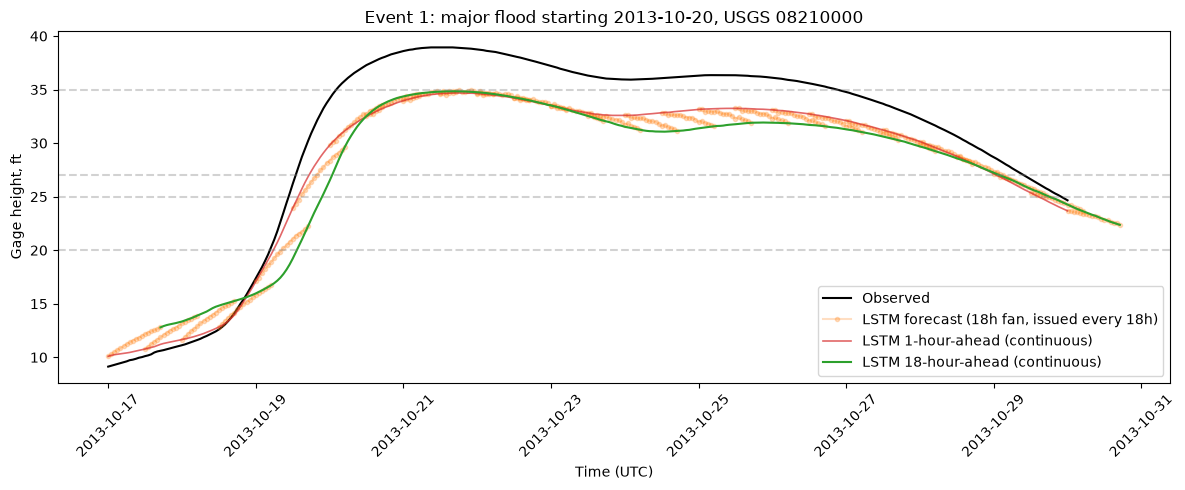

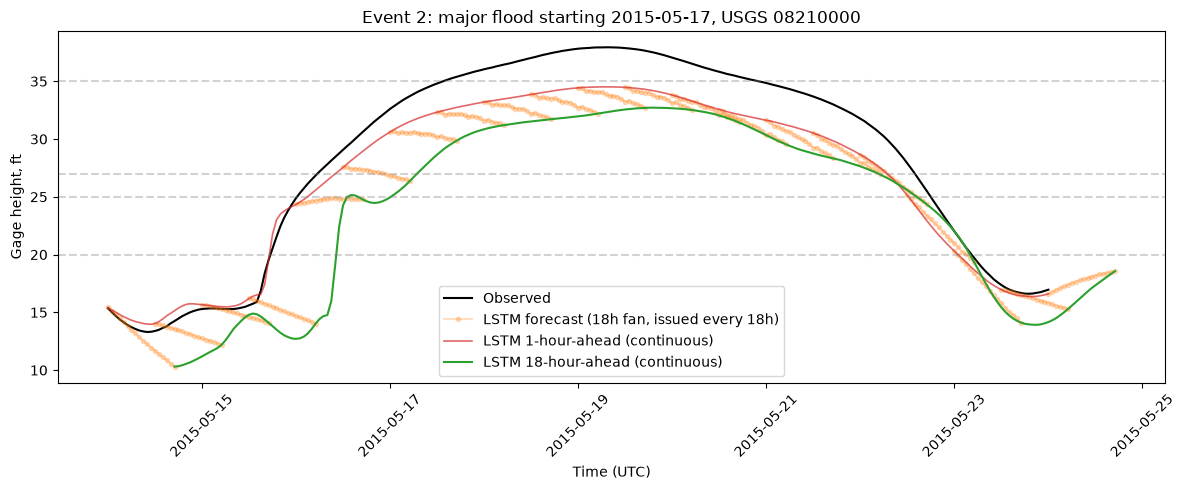

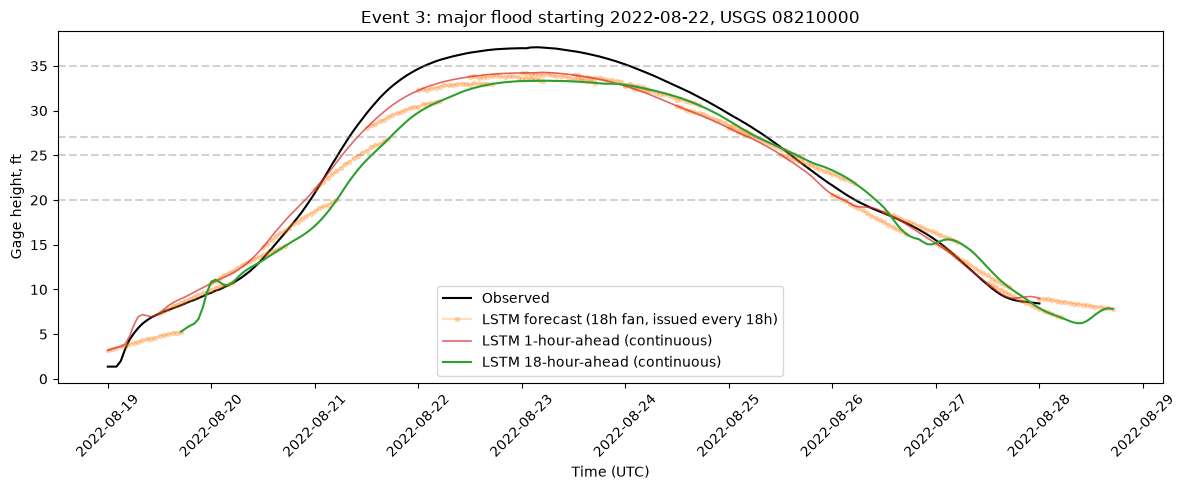

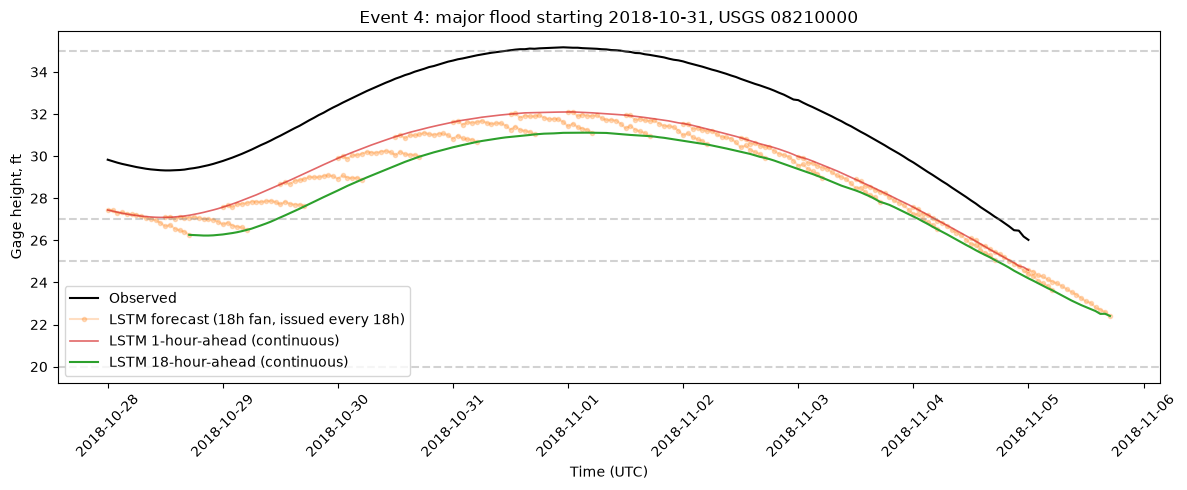

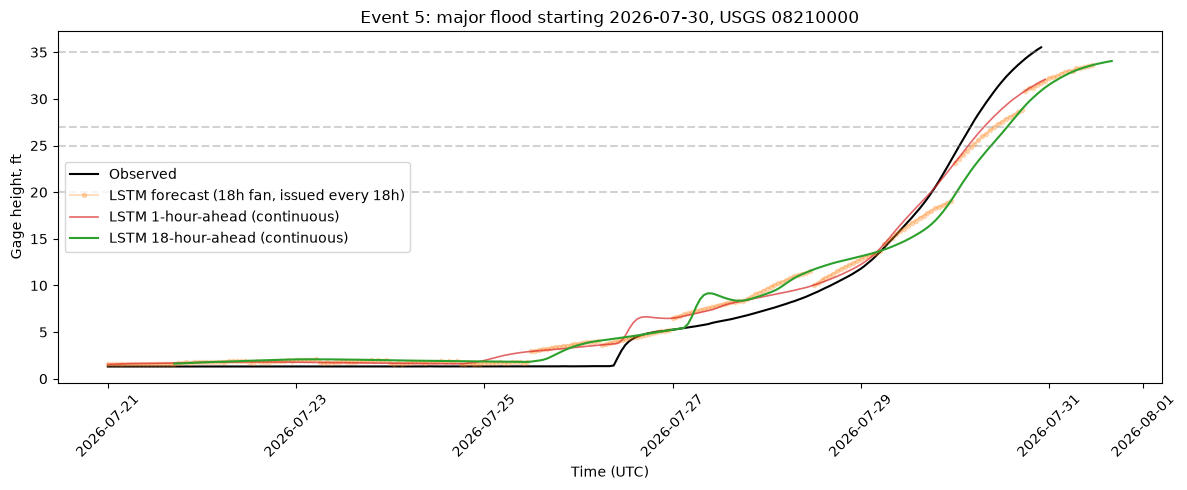

In [74]:
for _, event in events.iterrows():
    event_forecasts = forecast_results[
        forecast_results["event_rank"] == event["event_rank"]
    ]

    observed_series = stage_hourly.loc[
        event["requested_prediction_start_utc"]:
        event["requested_prediction_end_utc"],
        TARGET_GAUGE,
    ]

    plt.figure(figsize=(12, 5))
    plt.plot(
        observed_series.index, observed_series.values,
        label="Observed", color="black", linewidth=1.5,
    )

    first_forecast_line = True
    for issue_time, group in event_forecasts.groupby("issue_time"):
        plt.plot(
            group["forecast_time"], group["predicted_stage_ft"],
            marker="o", markersize=3, alpha=0.25, color="tab:orange",
            label="LSTM forecast (18h fan, issued every 18h)" if first_forecast_line else None,
        )
        first_forecast_line = False

    nowcast = nowcast_forecasts[event["event_rank"]]
    plt.plot(
        nowcast["forecast_time"], nowcast["predicted_stage_ft"],
        color="tab:red", linewidth=1.2, alpha=0.7,
        label="LSTM 1-hour-ahead (continuous)",
    )

    lead12 = lead12_forecasts[event["event_rank"]]
    plt.plot(
        lead12["forecast_time"], lead12["predicted_stage_ft"],
        color="tab:green", linewidth=1.5,
        label="LSTM 18-hour-ahead (continuous)",
    )

    for label, value in thresholds.items():
        if pd.notna(value):
            plt.axhline(value, linestyle="--", alpha=0.35, color="gray")

    plt.title(
        f"Event {event['event_rank']}: major flood starting "
        f"{event['major_event_start_utc'].date()}, USGS {TARGET_GAUGE}"
    )
    plt.xlabel("Time (UTC)")
    plt.ylabel("Gage height, ft")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


## Save results

In [77]:
forecast_results.to_csv("major_event_forecast_results_5_event.csv", index=False)
event_summary.to_csv("major_event_summary_5_event.csv", index=False)

print("Saved major_event_forecast_results.csv and major_event_summary.csv")


Saved major_event_forecast_results.csv and major_event_summary.csv


In [79]:
forecast_results

,event_rank,issue_time,lead_hour,forecast_time,predicted_stage_ft,observed_stage_ft,predicted_warning,observed_warning
0,1,2013-10-17 00:00:00+00:00,1,2013-10-17 00:00:00+00:00,10.091178,9.13,Below Action Stage,Below Action Stage
1,1,2013-10-17 00:00:00+00:00,2,2013-10-17 01:00:00+00:00,10.264685,9.21,Below Action Stage,Below Action Stage
2,1,2013-10-17 00:00:00+00:00,3,2013-10-17 02:00:00+00:00,10.502988,9.29,Below Action Stage,Below Action Stage
3,1,2013-10-17 00:00:00+00:00,4,2013-10-17 03:00:00+00:00,10.683746,9.37,Below Action Stage,Below Action Stage
4,1,2013-10-17 00:00:00+00:00,5,2013-10-17 04:00:00+00:00,10.861988,9.46,Below Action Stage,Below Action Stage
...,...,...,...,...,...,...,...,...
1759,5,2026-07-30 18:00:00+00:00,14,2026-07-31 07:00:00+00:00,33.278767,NaN,Moderate Flood,NaN
1760,5,2026-07-30 18:00:00+00:00,15,2026-07-31 08:00:00+00:00,33.294297,NaN,Moderate Flood,NaN
1761,5,2026-07-30 18:00:00+00:00,16,2026-07-31 09:00:00+00:00,33.411808,NaN,Moderate Flood,NaN
1762,5,2026-07-30 18:00:00+00:00,17,2026-07-31 10:00:00+00:00,33.514192,NaN,Moderate Flood,NaN
